In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import ta
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import load_stock_data

In [4]:
df = load_stock_data("AAPL.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

df["SMA_50"] = df["Close"].rolling(window=50).mean()

df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()

macd = ta.trend.MACD(df["Close"])

df["MACD"] = macd.macd()
df["MACD_signal"] = macd.macd_signal()

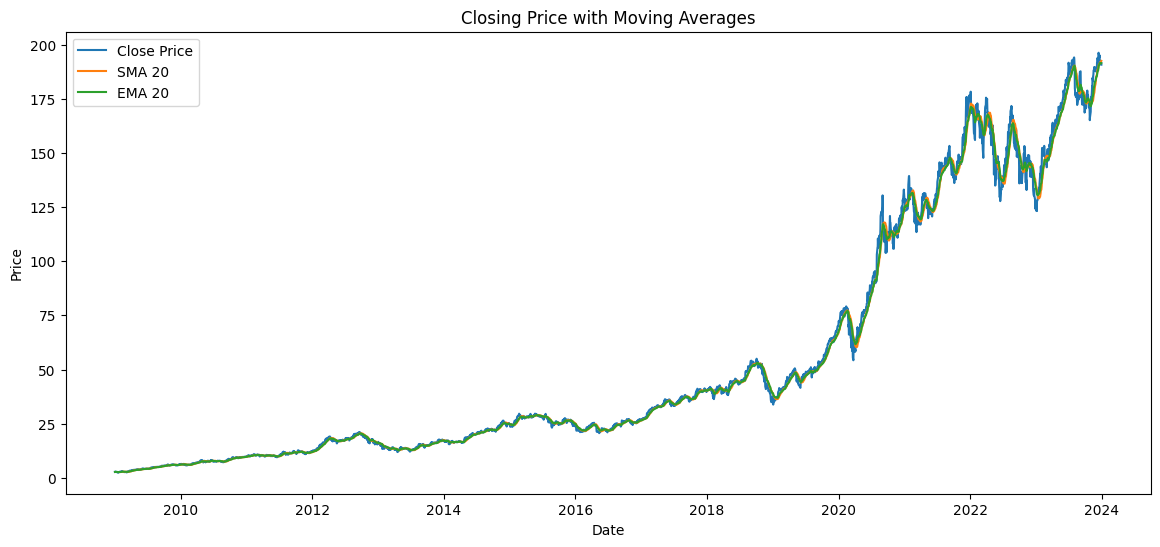

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

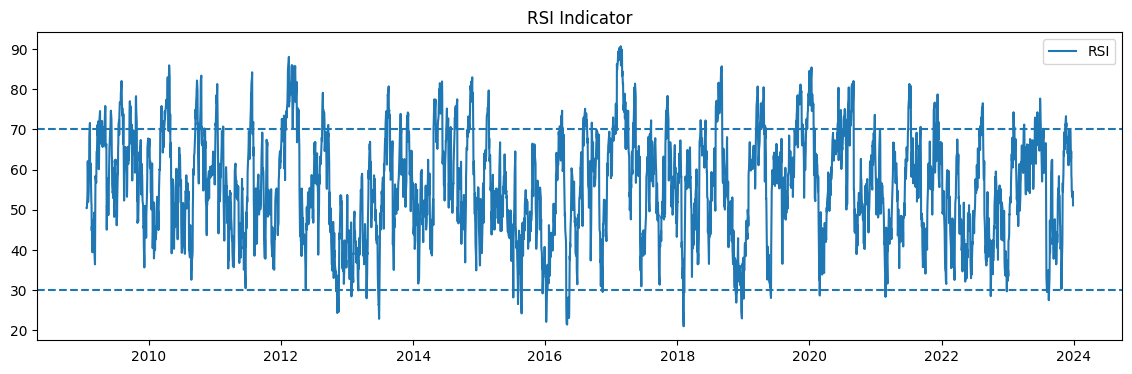

In [11]:
plt.figure(figsize=(14, 4))

plt.plot(df["Date"], df["RSI"], label="RSI")

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("RSI Indicator")

plt.legend()

plt.show()

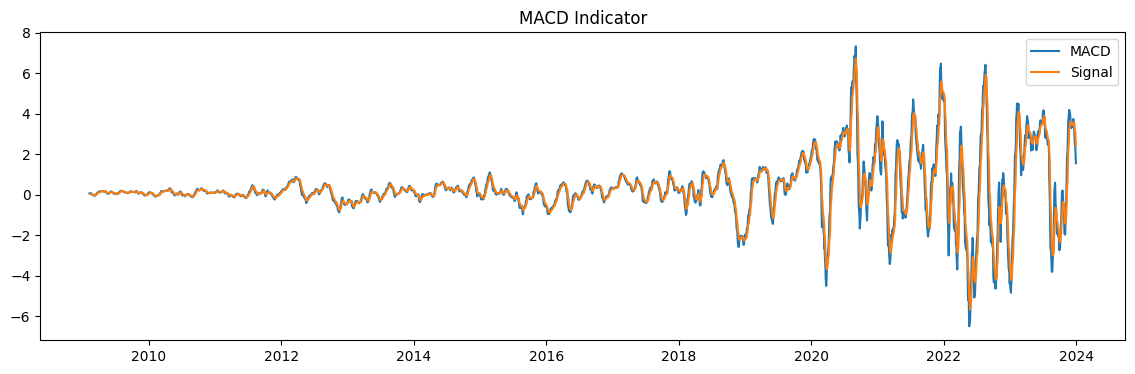

In [12]:
plt.figure(figsize=(14, 4))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_signal"], label="Signal")

plt.title("MACD Indicator")

plt.legend()

plt.show()